<a href="https://colab.research.google.com/github/zain4cs/function-transformer/blob/main/Function_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
aimport pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/train.csv", usecols=['Age','Fare','Survived'])

In [ ]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [ ]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

/tmp/ipykernel_7238/1698716155.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [ ]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
x = df.iloc[:, 1:3]
y = df.iloc[:,0]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

/tmp/ipykernel_7238/2335373563.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


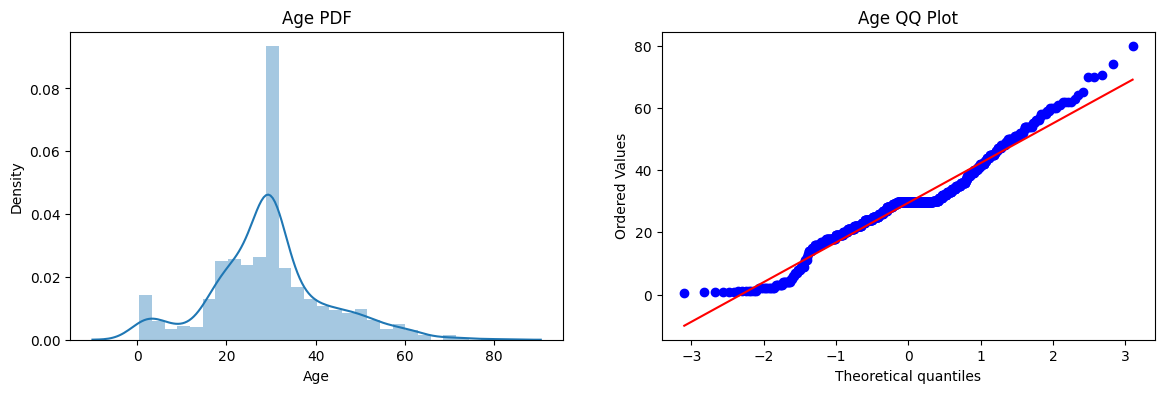

In [ ]:
# from scipy.stats.distributions import norm
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title("Age PDF")

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title("Age QQ Plot")

plt.show()

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title("Fare PDF")

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title("Fare QQ Plot")

plt.show()

In [ ]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [ ]:
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = clf.predict(X_test)
y_pred2 = clf2.predict(X_test)

In [ ]:
print(accuracy_score(y_test, y_pred))
print(accuracy_score(y_test, y_pred2))

0.6480446927374302
0.6871508379888268


_____________________________

**Now Apply Log / Function-Transformer**

In [ ]:
trf = FunctionTransformer(func=np.log1p)

In [ ]:
X_train_transformerd = trf.fit_transform(X_train)
X_test_transformerd = trf.transform(X_test)

In [ ]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformerd, y_train)
clf2.fit(X_train_transformerd, y_train)

y_pred = clf.predict(X_test_transformerd)
y_pred2 = clf2.predict(X_test_transformerd)

print("Accuracy LR",accuracy_score(y_test, y_pred))
print("Accuracy DT",accuracy_score(y_test, y_pred2))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6983240223463687


______________________

**Check Cross_Val_Score**

In [ ]:
X_transformed = trf.fit_transform(x)

clf = LogisticRegression()
clf2  = DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf, X_transformed, y, scoring='accuracy', cv=10)))
print("DT", np.mean(cross_val_score(clf2, X_transformed, y, scoring="accuracy", cv=10)))

LR 0.678027465667915
DT 0.6622222222222223


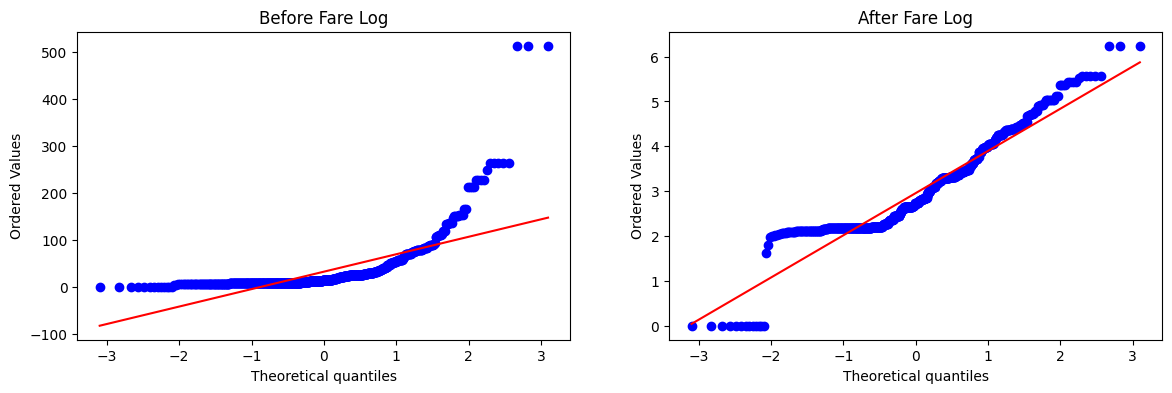

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title("Before Fare Log")

plt.subplot(122)
stats.probplot(X_train_transformerd['Fare'], dist="norm", plot=plt)
plt.title("After Fare Log")

plt.show()

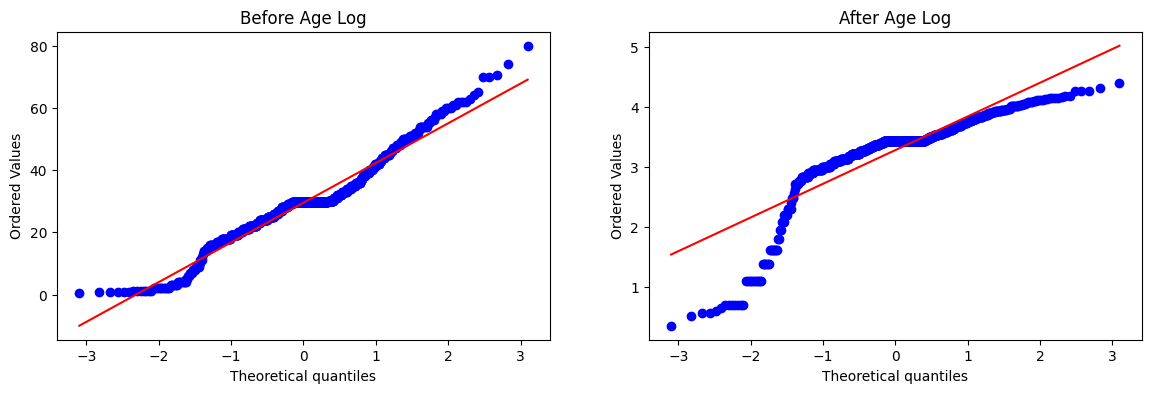

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title("Before Age Log")

plt.subplot(122)
stats.probplot(X_train_transformerd['Age'], dist="norm", plot=plt)
plt.title("After Age Log")

plt.show()